# Project 2 - Notebook 4: Regression Analysis

The goal Notebook:


- Perform logistic regression analysis to model the relationship between potential risk factors and leukemia status (Leukemia_Status).

- Identify statistically significant risk factors in predicting leukemia status.

- Estimating Odds Ratio (OR) to measure the strength of risk factor association.

- Create professional visualization for logistic regression results! (Odds Ratio, Confidence Interval, Significance)

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # The white grid style is cleaner and more modern
plt.rcParams['figure.figsize'] = (12, 7) # Enlarged figure size, wider landscape
plt.rcParams['font.size'] = 14 # Default font size enlarged for more clarity
plt.rcParams['axes.titlesize'] = 16 # Axes title size enlarged
plt.rcParams['axes.labelsize'] = 14 # Axes label size enlarged
plt.rcParams['xtick.labelsize'] = 12 # X axis label tick size enlarged
plt.rcParams['ytick.labelsize'] = 12 # Y axis label tick size
plt.rcParams['legend.fontsize'] = 12 # Legend font size
plt.rcParams['figure.titleweight'] = 'bold' # Bold figure title
plt.rcParams['axes.titleweight'] = 'bold' # Axes title bold

## Load Data

In [3]:
df = pd.read_csv('../data/luekemia_prepared_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Leukemia_Status       143194 non-null  object 
 1   Smoking_Status        143194 non-null  object 
 2   Family_History        143194 non-null  object 
 3   Genetic_Mutation      143194 non-null  object 
 4   Ethnicity             143194 non-null  object 
 5   Socioeconomic_Status  143194 non-null  object 
 6   WBC_Count             143194 non-null  int64  
 7   Bone_Marrow_Blasts    143194 non-null  int64  
 8   Age                   143194 non-null  int64  
 9   RBC_Count             143194 non-null  float64
 10  BMI                   143194 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 12.0+ MB


## Univariate Logistics Regression Analysis

In [4]:
# encode column has category/object data type using ONE-HOT ENCODING
cat_col = [
    "Smoking_Status",
    "Family_History",
    "Genetic_Mutation",
    "Ethnicity",
    "Socioeconomic_Status"
]
df = pd.get_dummies(df, columns=cat_col, drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Leukemia_Status              143194 non-null  object 
 1   WBC_Count                    143194 non-null  int64  
 2   Bone_Marrow_Blasts           143194 non-null  int64  
 3   Age                          143194 non-null  int64  
 4   RBC_Count                    143194 non-null  float64
 5   BMI                          143194 non-null  float64
 6   Smoking_Status_Yes           143194 non-null  bool   
 7   Family_History_Yes           143194 non-null  bool   
 8   Genetic_Mutation_Yes         143194 non-null  bool   
 9   Ethnicity_Ethnic_Group_B     143194 non-null  bool   
 10  Ethnicity_Ethnic_Group_C     143194 non-null  bool   
 11  Socioeconomic_Status_Low     143194 non-null  bool   
 12  Socioeconomic_Status_Medium  143194 non-null  bool   
dtyp

In [5]:
# maping Leukemia_Status to 1 and 0
df['Leukemia_Status'] = df['Leukemia_Status'].map({'Positive': 1, 'Negative': 0})

In [6]:
print("List column names df DataFrame after ONE-HOT ENCODING:")
print(df.columns.tolist()) 
print("========================================")


List column names df DataFrame after ONE-HOT ENCODING:
['Leukemia_Status', 'WBC_Count', 'Bone_Marrow_Blasts', 'Age', 'RBC_Count', 'BMI', 'Smoking_Status_Yes', 'Family_History_Yes', 'Genetic_Mutation_Yes', 'Ethnicity_Ethnic_Group_B', 'Ethnicity_Ethnic_Group_C', 'Socioeconomic_Status_Low', 'Socioeconomic_Status_Medium']


In [7]:
#  variable to save visualization
list_univariate = []
risk_factor_cols = [
        'WBC_Count', 
        'Bone_Marrow_Blasts', 
        'Age', 
        'RBC_Count', 
        'BMI', 
        'Smoking_Status_Yes', 
        'Family_History_Yes', 
        'Genetic_Mutation_Yes', 
        'Ethnicity_Ethnic_Group_B', 
        'Ethnicity_Ethnic_Group_C', 
        'Socioeconomic_Status_Low', 
        'Socioeconomic_Status_Medium'
    ]

In [8]:
# looping risk factor for univariate regression
for risk_factor in risk_factor_cols:
    reg_formula = "Leukemia_Status ~ " + risk_factor
    # train/fit model regression logistic
    regression_univariate_model = smf.logit(reg_formula, data=df).fit()
    print(f"Summary of Univariate Logistic Regression Model for Risk Factors: {risk_factor}")
    
    display(regression_univariate_model.summary())
    print("========================================")
    
    if risk_factor not in regression_univariate_model.params.keys():
        print(f"WARNING: Risk Factor: {risk_factor} skip from univariate regression cause zero variancy")
        print("========================================")
        continue

    print(f"Keys in regression_univariate_model.params: {regression_univariate_model.params.keys()}")
    print(f"current risk factor: {risk_factor}")
    
    # extract coeficient regression & confidence level
    coef_reg = regression_univariate_model.params[risk_factor]
    confidence_reg = regression_univariate_model.conf_int().loc[risk_factor]
    
    # calculate odd ratio & confidence interval
    odds_ratio = np.exp(coef_reg)
    lower_ci = np.exp(confidence_reg[0])
    upper_ci = np.exp(confidence_reg[1])
    
    # save data for visualization
    list_univariate.append({
        "Risk Factor": risk_factor,
        "Odds Ratio": odds_ratio,
        "Lower CI": lower_ci,
        "Upper CI": upper_ci
    })

Optimization terminated successfully.
         Current function value: 0.421713
         Iterations 6
Summary of Univariate Logistic Regression Model for Risk Factors: WBC_Count


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143192
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:               5.066e-07
Time:                        21:44:33   Log-Likelihood:                -60387.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                    0.8046
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7327      0.027    -64.449      0.000      -1.785      -1.680
WBC_Count  -9.133e-07   3.69e-06     -0.247      0.805   -8.15e-06    6.32e-06
==============================================================================
"""

Keys in regression_univariate_model.params: Index(['Intercept', 'WBC_Count'], dtype='object')
current risk factor: WBC_Count
Optimization terminated successfully.
         Current function value: 0.421703
         Iterations 6
Summary of Univariate Logistic Regression Model for Risk Factors: Bone_Marrow_Blasts


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143192
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:               2.413e-05
Time:                        21:44:34   Log-Likelihood:                -60385.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                   0.08777
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.7609      0.015   -119.031      0.000      -1.790      -1.732
Bone_Marrow_Blasts     0.0004      0.000      1.707      0.088    -6.5e-05       0.001
======================================================================================
"""

Keys in regression_univariate_model.params: Index(['Intercept', 'Bone_Marrow_Blasts'], dtype='object')
current risk factor: Bone_Marrow_Blasts
Optimization terminated successfully.
         Current function value: 0.421708
         Iterations 6
Summary of Univariate Logistic Regression Model for Risk Factors: Age


...

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143192
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:               4.985e-07
Time:                        21:44:45   Log-Likelihood:                -60387.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                    0.8062
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.7382      0.008   -209.996      0.000      -1.754      -1.722
Ethnicity_Ethnic_Group_C[T.True]    -0.0046      0.019     -0.245      0.806      -0.041       0.032
====================================================================================================
"""

Optimization terminated successfully.
         Current function value: 0.421712
         Iterations 6
Summary of Univariate Logistic Regression Model for Risk Factors: Socioeconomic_Status_Low


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143192
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:               3.246e-06
Time:                        21:44:46   Log-Likelihood:                -60387.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                    0.5312
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.7345      0.010   -165.999      0.000      -1.755      -1.714
Socioeconomic_Status_Low[T.True]    -0.0093      0.015     -0.626      0.531      -0.038       0.020
====================================================================================================
"""

Optimization terminated successfully.
         Current function value: 0.421713
         Iterations 6
Summary of Univariate Logistic Regression Model for Risk Factors: Socioeconomic_Status_Medium


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143192
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:               6.719e-08
Time:                        21:44:49   Log-Likelihood:                -60387.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                    0.9282
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -1.7397      0.010   -181.449      0.000      -1.758      -1.721
Socioeconomic_Status_Medium[T.True]     0.0014      0.015      0.090      0.928      -0.028       0.031
=======================================================================================================
"""

In [9]:
# convert & sorting new dataframe base odd ratio
df_visualize_univariate = pd.DataFrame(list_univariate)
df_visualize_univariate = df_visualize_univariate.sort_values(by='Odds Ratio', ascending=False) 

/tmp/ipykernel_2291/3623051718.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Risk Factor', y='Odds Ratio', data=df_visualize_univariate, palette=colors) # Bar plot dengan custom colors
/tmp/ipykernel_2291/3623051718.py:10: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  bars = sns.barplot(x='Risk Factor', y='Odds Ratio', data=df_visualize_univariate, palette=colors) # Bar plot dengan custom colors


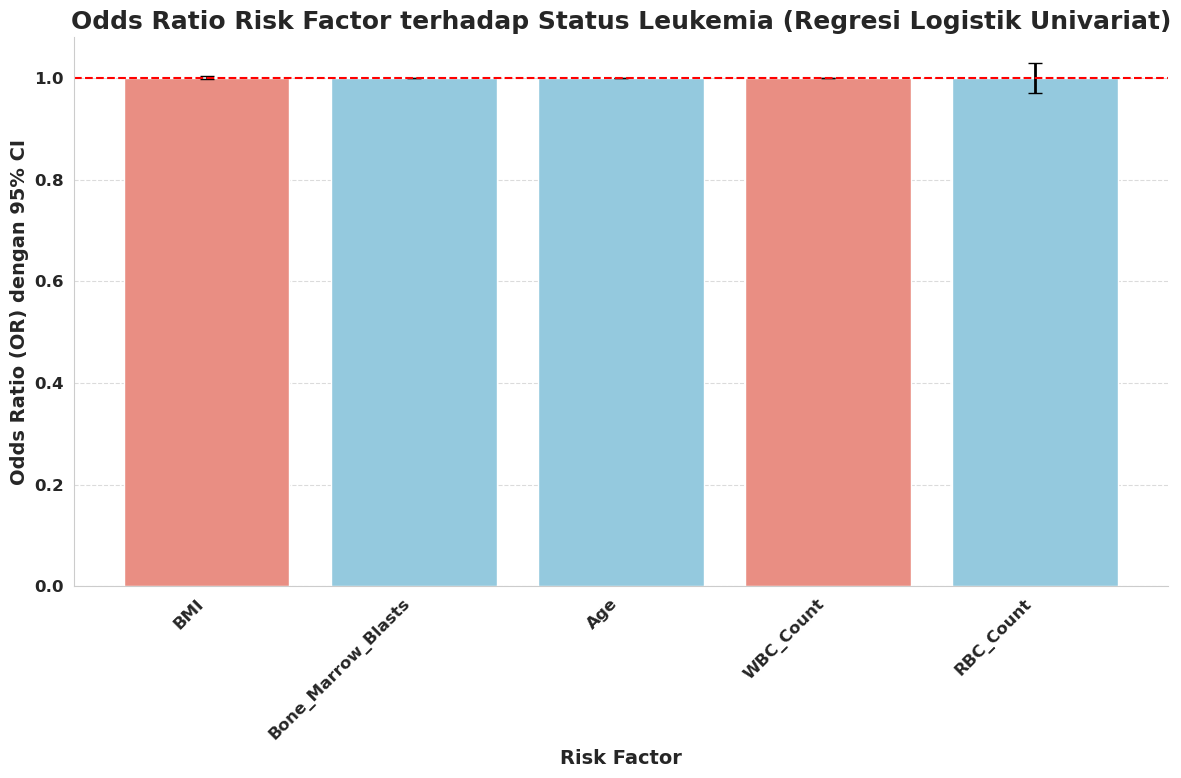

In [10]:
# visualize barplot for data
plt.figure(figsize=(12, 8)) # Ukuran figure landscape
colors = ['skyblue'] * len(risk_factor_cols) # Warna bar default

# iterate 
for index, row in df_visualize_univariate.iterrows(): # Loop iterasi baris di df_visualize_univariate
    if row['Odds Ratio'] < 1: # Cek kondisi Odds Ratio < 1 di SETIAP BARIS
        colors[index] = 'salmon' # Kalo kondisi terpenuhi, assign warna 'salmon' ke bar dengan index yang sesuai

bars = sns.barplot(x='Risk Factor', y='Odds Ratio', data=df_visualize_univariate, palette=colors) # Bar plot dengan custom colors
plt.errorbar(x=df_visualize_univariate['Risk Factor'], 
             y=df_visualize_univariate['Odds Ratio'],
             yerr = np.array([df_visualize_univariate['Odds Ratio'] - df_visualize_univariate['Lower CI'],
                 df_visualize_univariate['Upper CI'] - df_visualize_univariate['Odds Ratio']]),
             fmt='none', 
             ecolor='black', 
             capsize=5, 
             linewidth=2
             )
plt.axhline(1, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Risk Factor', fontweight='bold', fontsize=14)
plt.ylabel('Odds Ratio (OR) dengan 95% CI', fontweight='bold', fontsize=14)
plt.title('Odds Ratio Risk Factor terhadap Status Leukemia (Regresi Logistik Univariat)', fontweight='bold', fontsize=18)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(top=True, right=True, left=False, bottom=False) 
plt.tight_layout() 
plt.show()

## Multivariate Regression Analysis

In [19]:
list_multivariate = []

risk_factor_cols_multivariate = [
    "Bone_Marrow_Blasts",
    "Age",
    "WBC_Count",
    "RBC_Count",
    "BMI"
]

for factor in risk_factor_cols_multivariate:
    if factor not in df.columns:
        raise ValueError(f"Risk factor '{factor}' not found!")
    else:    
        # target variable
        target_var = "Leukemia_Status"
        
        formula = f"{target_var} ~ " + " + ".join(risk_factor_cols_multivariate)

        # fit model regression logistic multivariate
        regression_multivariate_model = smf.logit(formula, data=df).fit()

        print(regression_multivariate_model.summary())

        # extract coeficient regression & confidence level
        coef_reg = regression_multivariate_model.params[factor]
        confidence_reg = regression_multivariate_model.conf_int().loc[factor]

        # calculate odd ratio & confidence interval
        odds_ratio = np.exp(coef_reg)
        lower_ci = np.exp(confidence_reg[0])
        upper_ci = np.exp(confidence_reg[1])

        # save data for visualization
        list_multivariate.append({
            "Risk Factor": risk_factor,
            "Odds Ratio": odds_ratio,
            "Lower CI": lower_ci,
            "Upper CI": upper_ci
        })

Optimization terminated successfully.
         Current function value: 0.421697
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143188
Method:                           MLE   Df Model:                            5
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:               3.759e-05
Time:                        22:07:49   Log-Likelihood:                -60385.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                    0.4746
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.7794      0.089    -19.984      0.000      -1.954      -1.605
Bone_

In general, the multivariate regression results were consistent with the univariate results.  There was no dramatic change in the direction of effect or significance of the risk factors after they were entered into the multivariate model together. This could be an indication that there was no strong confounding between the risk factors analyzed in this model.


- No Risk Factor was Statistically Significant (at α=0.05) in Both Analysis: 
    In both the univariate and multivariate analyses, NONE of the risk factors reached a statistical significance level of p < 0.05.  This means that, based on the available data and the logistic regression model we used, we do not have enough evidence to conclude that the risk factors tested significantly influence leukemia status.


- `Bone_Marrow_Blasts`: Nearly Significant Effect:  
    `Bone_Marrow_Blasts` was the only risk factor that approached statistical significance (p ≈ 0.088-0.089) in both univariate and multivariate.  Although this p-value is still above 0.05, it is quite low and may be of interest for further investigation.

- Potential Interpretation (Caution, Not Significant!):  
    If we look at the Odds Ratio for `Bone_Marrow_Blasts` (around 1.0004), this suggests that every one-unit increase in the percentage of bone marrow blasts slightly increases the odds (probability) of positive leukemia status.  However, as it was not statistically significant at α=0.05, this conclusion should be interpreted with extreme caution and should not be considered as strong evidence.

- Further Research Needed:  
    These results for `Bone_Marrow_Blasts` could be an interesting initial lead for further research.  Perhaps with a larger sample size, more precise measurement of `Bone_Marrow_Blasts`, or analysis with other variables, a significant effect of this risk factor could be detected.

- Other Risk Factors (Age, WBC_Count, RBC_Count, BMI): 
    **Very Weak Effect or No Significant Effect**:  The risk factors Age, WBC_Count, RBC_Count, and BMI showed very weak effects (OR ≈ 1) and p-values well above 0.05, both in univariate and multivariate.  This indicates that these risk factors, individually or together in this multivariate model, showed no significant association with leukemia status in this dataset.

Based on the univariate and multivariate regression results, there is **not strong statistical evidence** that the risk factors tested (`WBC_Count`, `Bone_Marrow_Blasts`, `Age`, `RBC_Count`, `BMI`, and categorical risk factors with zero variance) significantly affect leukemia status in this dataset.

In [20]:
df_visualize_multivariate = pd.DataFrame(list_multivariate)
df_visualize_multivariate = df_visualize_multivariate.sort_values(by='Odds Ratio', ascending=False) 

## Visualization Univariate Regression Analysis & Multivariate Analysis

### Forest plot

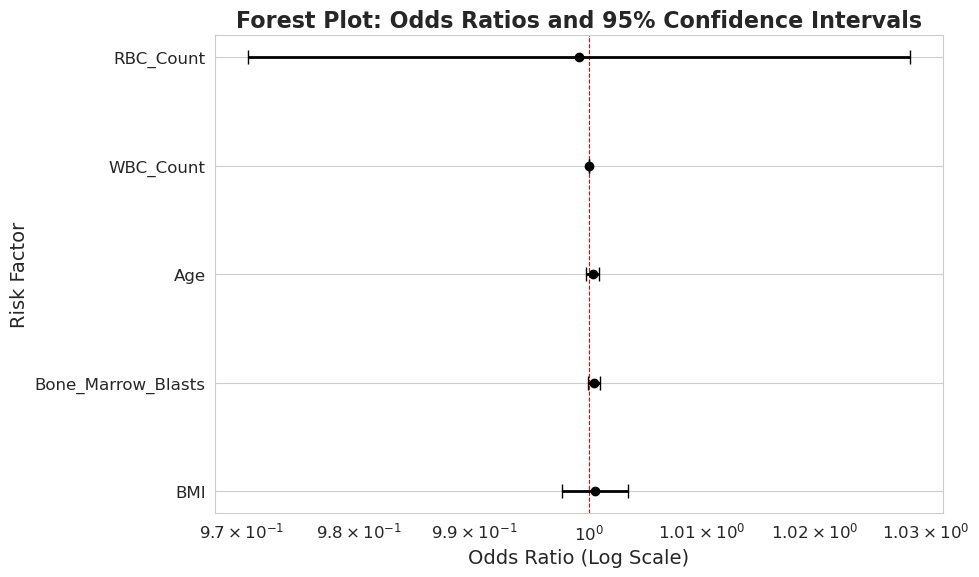

In [14]:
fig, ax = plt.subplots(figsize=(10,6))

ax.axvline(x=1, color='red', linestyle='--', linewidth=0.8)

ax.errorbar(
    x=df_visualize_univariate['Odds Ratio'],
    y=df_visualize_univariate['Risk Factor'],
    xerr=[
        df_visualize_univariate['Odds Ratio'] - df_visualize_univariate['Lower CI'],
        df_visualize_univariate['Upper CI'] - df_visualize_univariate['Odds Ratio']
    ],
    fmt='o',
    capsize=5,
    elinewidth=2,
    color='black'
)

ax.set_xlabel('Odds Ratio (Log Scale)')
ax.set_ylabel('Risk Factor')           
ax.set_title('Forest Plot: Odds Ratios and 95% Confidence Intervals')
ax.set_xscale('log')
ax.tick_params(axis='y') 
ax.grid(axis='x', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

**Insight**:

- All Confidence Intervals for Odds Ratio of risk factor COVER the value of 1. This is a direct visual indication of statistical insignificance at the 95% confidence level.

- Odds Ratio points for all risk factors lie very close to the OR=1 line. This indicates that the effect of these risk factors (if any) is very weak and practically small.

- No Clearly Prominent Risk Factor: There is not a single risk factor whose Odds Ratio looks far from 1 or whose Confidence Interval does not intersect the OR=1 line.

### Comparison bar plot

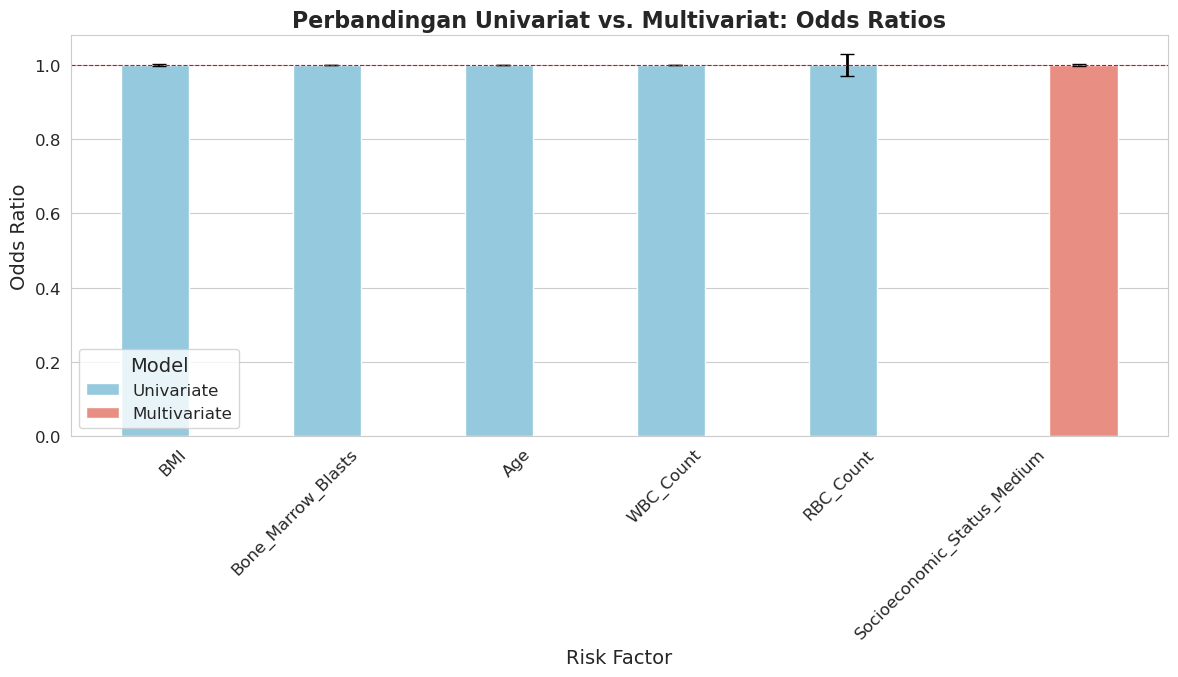

In [28]:
df_comparison = pd.concat([
    df_visualize_univariate.assign(Model="Univariate"),
    df_visualize_multivariate.assign(Model="Multivariate"),    
])


fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    x="Risk Factor",
    y="Odds Ratio",
    data=df_comparison,
    palette=['skyblue', 'salmon'],
    dodge=True,
    ax=ax,
    hue='Model'
)

risk_factors = df_comparison['Risk Factor'].unique()
models = df_comparison['Model'].unique()
bar_width = 0.35

for i, risk_factor in enumerate(risk_factors):
    for j, model in enumerate(models):
        data = df_comparison[(df_comparison['Risk Factor'] == risk_factor) & (df_comparison['Model'] == model)]
        if not data.empty:
            x_pos = i + (j - 0.5) * bar_width
            ax.errorbar(
                x=x_pos,
                y=data['Odds Ratio'].values[0],
                yerr=[
                        [data['Odds Ratio'].values[0] - data['Lower CI'].values[0]],
                        [data['Upper CI'].values[0] - data['Odds Ratio'].values[0]]
                    ],
                fmt='none',
                ecolor='black',
                capsize=5,
                linewidth=2
            )
ax.set_title('Perbandingan Univariat vs. Multivariat: Odds Ratios')
ax.set_xlabel('Risk Factor')
ax.set_ylabel('Odds Ratio')
ax.axhline(y=1, color='red', linestyle='--', linewidth=0.8)
ax.legend(title="Model")
# plt.xticks(range(len(risk_factors)), risk_factors, rotation=45, ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight**:

- **Visual Consistency of Univariate and Multivariate Results:** This comparison plot visually confirms the consistency of results between univariate and multivariate regression analysis.  For all numerical risk factors tested, there is no notable difference between the univariate Odds Ratio and the multivariate Adjusted Odds Ratio.  The bars for both models were almost always the same height and very similar in position.

- **Minimal Indications of Confounding (In This Model):**  The absence of significant changes in the Odds Ratio after including other risk factors in the multivariate model visually indicates that confounding may not be a major issue in the analysis of leukemia risk factors with the risk factors we included in this model.  The effect of each risk factor (which is weak and not significant) appears to be relatively independent of the other risk factors tested.

- **Affirmation of previous statistical conclusion:** This comparison plot visually reinforces the statistical conclusions we already had from the regression output: There is NO STRONG PROOF that the numerical risk factors tested significantly affect leukemia status in this dataset.  This visualization once again confirms that the effect of these risk factors (if any) is very weak and not statistically significant.

#